# Integrating Analysis and Visualisation

## Case Study 1 — Business: Retail Sales Analytics

### Dataset overview

In [8]:
import urllib.request
import os

os.makedirs("../data/raw", exist_ok=True)

url  = ("https://archive.ics.uci.edu/static/public/502/"
        "online+retail+ii.zip")
dest = "../data/raw/online_retail_II.zip"

if not os.path.exists(dest):
    print("Downloading Online Retail II dataset…")
    urllib.request.urlretrieve(url, dest)

import zipfile
with zipfile.ZipFile(dest) as z:
    z.extractall("../data/raw/")
    print("Extracted:", z.namelist())

Extracted: ['online_retail_II.xlsx']


### Stage 1 — Ingestion and audit

In [2]:
import sys
import os
sys.path.append(os.path.abspath("../src"))
from pipeline import load_raw, audit
from config import RETAIL_CONFIG

df_raw = load_raw(RETAIL_CONFIG["filename"], cfg=RETAIL_CONFIG)

report = audit(df_raw)
print(f"Shape:      {report['shape']}")
print(f"Duplicates: {report['duplicates']:,}")
print("\nNull percentages:")
for col, pct in report['null_pct'].items():
    if pct > 0:
        print(f"  {col:<20} {pct:.1f}%")

Shape:      (541910, 8)
Duplicates: 5,268

Null percentages:
  Description          0.3%
  Customer ID          24.9%


**Visualise the null landscape before cleaning:**

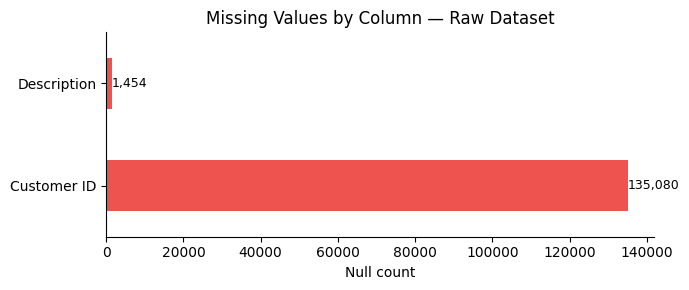

In [4]:
import matplotlib.pyplot as plt

null_counts = df_raw.isnull().sum()
null_counts = null_counts[null_counts > 0].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 3))
null_counts.plot(kind="barh", ax=ax, color="#EF5350")
ax.set_xlabel("Null count")
ax.set_title("Missing Values by Column — Raw Dataset")
ax.spines[["top","right"]].set_visible(False)
for i, v in enumerate(null_counts):
    ax.text(v + 50, i, f"{v:,}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/retail_nulls.png", dpi=150)
plt.show()

### Stage 2 — Cleaning

In [5]:
import os
import system

sys.path.append(os.path.abspath("../src"))
from pipeline import clean
from config import RETAIL_CONFIG

df_clean = df_raw.copy()

# Remove cancellations (Invoice starts with 'C')
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]

# Remove returns and zero-price rows
df_clean = df_clean[
    (df_clean["Quantity"] >= 1) &
    (df_clean["Price"]    >= 0.01)
]

print(f"Raw rows:        {len(df_raw):,}")
print(f"After cleaning:  {len(df_clean):,}")

Raw rows:        541,910
After cleaning:  530,101


### Stage 3 — Feature engineering and EDA

In [6]:
import pandas as pd
import numpy as np
from lets_plot import *
LetsPlot.setup_html()

df = df_clean.copy()
df["Revenue"]   = df["Quantity"] * df["Price"]
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M").astype(str)
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()
df["Hour"]      = df["InvoiceDate"].dt.hour

# Drop null Customer IDs after Revenue is added
df_customers = df.dropna(subset=["Customer ID"]).copy()
print(f"With customer ID: {len(df_customers):,}")

# --- Distribution of transaction revenue ---
sample = df[df["Revenue"] < 200].sample(30_000, random_state=42)

p_dist = (
    ggplot(sample, aes(x="Revenue"))
    + geom_histogram(bins=60, fill="#1565C0", alpha=0.8, color="white")
    + labs(title="Transaction Revenue Distribution (< £200)",
           x="Revenue (£)", y="Count")
    + theme_light()
    + ggsize(650, 320)
)

# Save the plots
from pathlib import Path
output_path = Path("../outputs/").resolve()

# Save the interactive plot as HTML
p_dist_html = "ggplot_revenue_distribution.html"
ggsave(p_dist, filename=str(output_path / p_dist_html))

# Save as PNG (scaled)
p_dist_png = "ggplot_revenue_distribution.png"
ggsave(p_dist, filename=str(output_path /p_dist_png ), scale=2)

p_dist

With customer ID: 397,881


In [7]:
# --- Sales by day of week ---
dow_order = ["Monday","Tuesday","Wednesday","Thursday",
             "Friday","Saturday","Sunday"]
dow = (
    df.groupby("DayOfWeek")["Revenue"]
    .sum().reindex(dow_order)
    .reset_index()
    .rename(columns={"Revenue":"total_revenue"})
)

p_dow = (
    ggplot(dow, aes(x="DayOfWeek", y="total_revenue",
                    fill="total_revenue"))
    + geom_bar(stat="identity", show_legend=False)
    + scale_fill_gradient(low="#BBDEFB", high="#1565C0")
    + scale_x_discrete(limits=dow_order)
    + labs(title="Total Revenue by Day of Week",
           x="Day", y="Revenue (£)")
    + theme_light()
    + ggsize(650, 320)
)

# Save the plots
from pathlib import Path
output_path = Path("../outputs/").resolve()

# Save the interactive plot as HTML
p_dow_html = "ggplot_dow_revenue.html"
ggsave(p_dow, filename=str(output_path / p_dow_html))

# Save as PNG (scaled)
p_dow_png = "ggplot_dow_revenue.png"
ggsave(p_dow, filename=str(output_path /p_dow_png ), scale=2)

p_dow

In [8]:
# --- Top 10 countries by revenue ---
country_rev = (
    df.groupby("Country")["Revenue"]
    .sum()
    .nlargest(10)
    .reset_index()
    .rename(columns={"Revenue":"total_revenue"})
    .sort_values("total_revenue")
)

p_country = (
    ggplot(country_rev, aes(x="total_revenue", y="Country"))
    + geom_bar(stat="identity", fill="#43A047")
    + labs(title="Top 10 Countries by Revenue",
           x="Revenue (£)", y="Country")
    + theme_light()
    + ggsize(650, 340)
)

# Save the plots
from pathlib import Path
output_path = Path("../outputs/").resolve()

# Save the interactive plot as HTML
p_country_html = "ggplot_top_countries.html"
ggsave(p_country, filename=str(output_path / p_country_html))
# Save as PNG (scaled)
p_country_png = "ggplot_top_countries.png"
ggsave(p_country, filename=str(output_path / p_country_png), scale=2)

p_country

### Stage 4 — Monthly revenue and RFM analysis

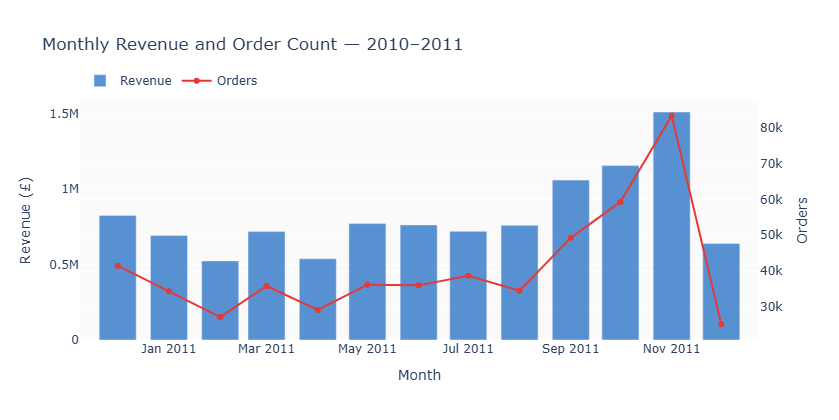

In [9]:
from pipeline import monthly_revenue, top_products, customer_rfm
from pipeline import plot_monthly_revenue, plot_top_products, plot_rfm_scatter
from config import RETAIL_CONFIG

# Monthly revenue trend
monthly = monthly_revenue(df)

fig_monthly = plot_monthly_revenue(
    monthly,
    title="Monthly Revenue and Order Count — 2010–2011"
)
fig_monthly.write_html("../outputs/plotly_monthly_revenue.html")
fig_monthly.write_image("../outputs/plotly_monthly_revenue.png", scale=2)
fig_monthly.show()

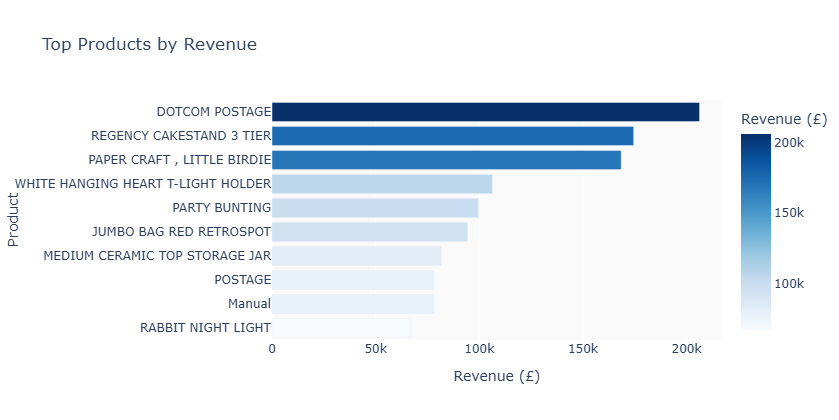

In [14]:
# Top 10 products
top10    = top_products(df, n=10)
fig_top  = plot_top_products(top10)
fig_top.write_html("../outputs/plotly_top_products.html")
fig_top.write_image("../outputs/plotly_top_products.png", scale=2)
fig_top.show()

In [13]:
# RFM segmentation
import pandas as pd

rfm = customer_rfm(df_customers, cfg=RETAIL_CONFIG)

# Assign RFM quintile scores (5 = best)
for col in ["recency","frequency","monetary"]:
    _, bins = pd.qcut(rfm[col], q=5, retbins=True, duplicates="drop")
    n_bins = len(bins) - 1
    labels = list(range(n_bins, 0, -1)) if col == "recency" \
             else list(range(1, n_bins + 1))
    rfm[f"{col}_score"] = pd.qcut(
        rfm[col], q=5, labels=labels, duplicates="drop"
    ).astype(int)

rfm["rfm_segment"] = (
    rfm["recency_score"].astype(str) +
    rfm["frequency_score"].astype(str) +
    rfm["monetary_score"].astype(str)
)

def label_segment(row):
    if row["frequency_score"] >= 4 and row["monetary_score"] >= 4:
        return "Champions"
    elif row["recency_score"] >= 4:
        return "Recent Buyers"
    elif row["frequency_score"] >= 3:
        return "Loyal"
    elif row["recency_score"] <= 2:
        return "At Risk"
    else:
        return "Others"

rfm["segment"] = rfm.apply(label_segment, axis=1)
print(rfm["segment"].value_counts())

segment
At Risk          1505
Recent Buyers    1199
Champions         688
Others            594
Loyal             352
Name: count, dtype: int64


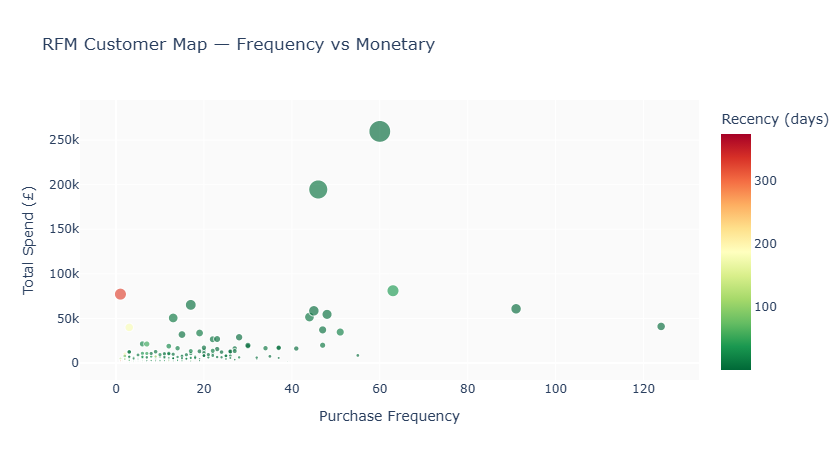

In [15]:
# RFM scatter using the shared pipeline function
fig_rfm = plot_rfm_scatter(rfm)
fig_rfm.write_html("../outputs/plotly_RFM_scatter.html")
fig_rfm.write_image("../outputs/plotly_RFM_scatter.png", scale=2)
fig_rfm.show()

**Save processed outputs**

In [16]:
from pipeline import save_processed
from config import RETAIL_CONFIG

# Ensure mixed-type columns are stored as strings before writing to Parquet
df["Invoice"]     = df["Invoice"].astype(str)
df["StockCode"]   = df["StockCode"].astype(str)
df["Description"] = df["Description"].astype(str)

save_processed(df,      "retail_clean.parquet",   cfg=RETAIL_CONFIG)
save_processed(monthly, "retail_monthly.parquet",  cfg=RETAIL_CONFIG)
save_processed(rfm,     "retail_rfm.parquet",      cfg=RETAIL_CONFIG)

Saved 530,101 rows → ..\data\processed\retail_clean.parquet
Saved 13 rows → ..\data\processed\retail_monthly.parquet
Saved 4,338 rows → ..\data\processed\retail_rfm.parquet


### Stage 5 — Communication: Streamlit retail dashboard

Open termianl from the root folder, activate your virtual environment:
```bash
cd src
streamlit run retail_dashboard.py
```

## Case Study 2 — Finance: Equity Price Analysis

### Stage 1 — Download and validate

In [1]:
import yfinance as yf
import pandas as pd
import os

os.makedirs("../data/raw", exist_ok=True)

TICKERS    = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]
START_DATE = "2019-01-01"
END_DATE   = "2023-12-31"

raw_path = "../data/raw/tech_stocks.parquet"

if not os.path.exists(raw_path):
    prices = yf.download(
        TICKERS, start=START_DATE, end=END_DATE,
        auto_adjust=True, progress=False
    )["Close"]
    prices.to_parquet(raw_path)
    print(f"Downloaded {prices.shape[0]} trading days for {len(TICKERS)} tickers.")
else:
    prices = pd.read_parquet(raw_path)

print(prices.shape)       # (~1258, 5)
print(prices.head(3))
print(prices.isnull().sum())

(1258, 5)
Ticker           AAPL       AMZN      GOOGL       MSFT      NVDA
Date                                                            
2019-01-02  37.503719  76.956497  52.301727  94.397156  3.376983
2019-01-03  33.768070  75.014000  50.853199  90.924461  3.172956
2019-01-04  35.209602  78.769501  53.461643  95.153305  3.376240
Ticker
AAPL     0
AMZN     0
GOOGL    0
MSFT     0
NVDA     0
dtype: int64


### Stage 2 — Feature engineering: returns and rolling statistics

In [2]:
import os
import sys
sys.path.append(os.path.abspath("../src"))
import numpy as np
from config import FINANCE_CONFIG

# Daily log returns: ln(P_t / P_{t-1})
log_returns = np.log(prices / prices.shift(1)).dropna()

# Rolling statistics using window sizes from config
w20 = FINANCE_CONFIG["window_20"]
w60 = FINANCE_CONFIG["window_60"]

rolling_mean_20 = prices.rolling(w20).mean()
rolling_std_20  = prices.rolling(w20).std()
rolling_mean_60 = prices.rolling(w60).mean()

# Annualised volatility (252 trading days)
ann_vol = log_returns.std() * np.sqrt(252)
print("Annualised Volatility:")
print(ann_vol.round(3))

Annualised Volatility:
Ticker
AAPL     0.322
AMZN     0.352
GOOGL    0.318
MSFT     0.305
NVDA     0.515
dtype: float64


### Stage 3 — EDA: price chart with rolling averages

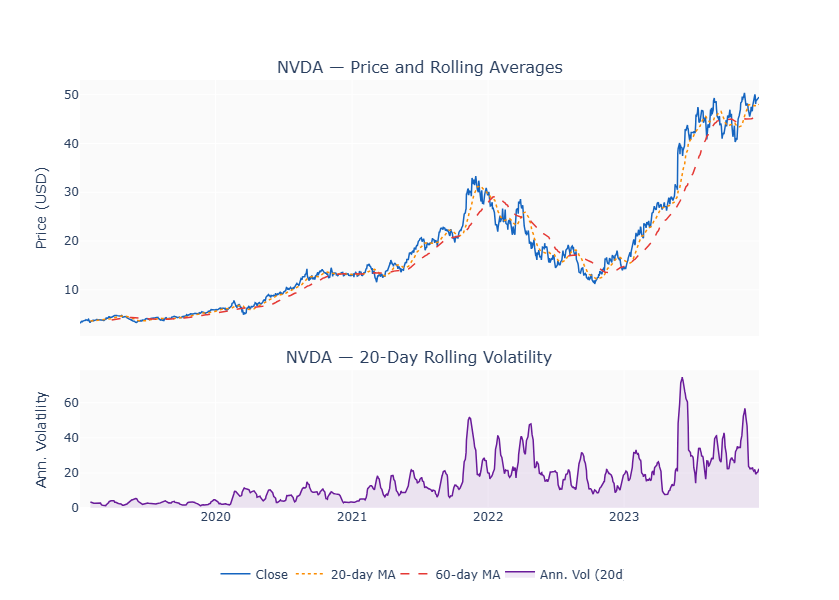

In [3]:
from pipeline import plot_price_with_ma

fig = plot_price_with_ma(
    prices, ticker="NVDA",
    rolling_mean_20=rolling_mean_20,
    rolling_mean_60=rolling_mean_60,
    rolling_std_20=rolling_std_20,
)
fig.write_html("../outputs/plotly_price_with_ma.html")
fig.write_image("../outputs/plotly_price_with_ma.png", scale=2)
fig.show()

### Stage 3 — EDA: return distributions and correlation

In [4]:
from lets_plot import *
LetsPlot.setup_html()
import pandas as pd

# Melt log returns to long format for Lets-Plot
lr_long = (
    log_returns.reset_index()
    .melt(id_vars="Date", var_name="Ticker", value_name="log_return")
)

# Distribution of daily log returns — faceted by ticker
p_dist = (
    ggplot(lr_long, aes(x="log_return", fill="Ticker"))
    + geom_density(alpha=0.5, color="white")
    + facet_wrap("Ticker", ncol=5)
    + scale_fill_brewer(type="qual", palette="Set1", guide="none")
    + labs(title="Daily Log Return Distributions — 2019–2023",
           x="Log Return", y="Density")
    + theme_light()
    + ggsize(900, 280)
)

# Save the plots
from pathlib import Path
output_path = Path("../outputs/").resolve()
# Save the interactive plot as HTML
p_dist_html = "ggplot_return_distribution.html"
ggsave(p_dist, filename=str(output_path / p_dist_html))
# Save as PNG (scaled)
p_dist_png = "ggplot_return_distribution.png"
ggsave(p_dist, filename=str(output_path / p_dist_png), scale=2)

p_dist

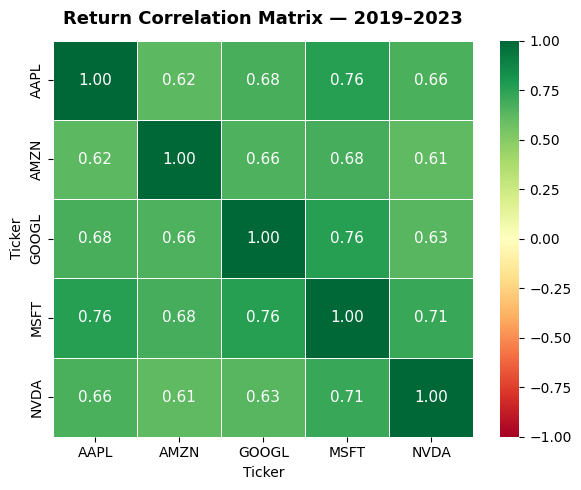

In [5]:
# Correlation heatmap of returns
import seaborn as sns
import matplotlib.pyplot as plt

corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    corr, annot=True, fmt=".2f",
    cmap="RdYlGn", vmin=-1, vmax=1,
    linewidths=0.5, linecolor="white",
    ax=ax, annot_kws={"size": 11}
)
ax.set_title("Return Correlation Matrix — 2019–2023",
             fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../outputs/finance_correlation.png", dpi=150)
plt.show()

### Stage 4 — Aggregation: risk–return summary

In [6]:
from pipeline import finance_summary, plot_risk_return
from config import FINANCE_CONFIG

summary = finance_summary(prices, log_returns, FINANCE_CONFIG["tickers"])
print(summary.to_string(index=False))

ticker  ann_return  ann_volatility  sharpe_ratio  max_drawdown
  AAPL       0.385           0.322         1.010        -0.314
  MSFT       0.146           0.352         0.387        -0.561
 GOOGL       0.215           0.318         0.613        -0.443
  AMZN       0.314           0.305         0.897        -0.371
  NVDA       0.712           0.515         1.045        -0.663


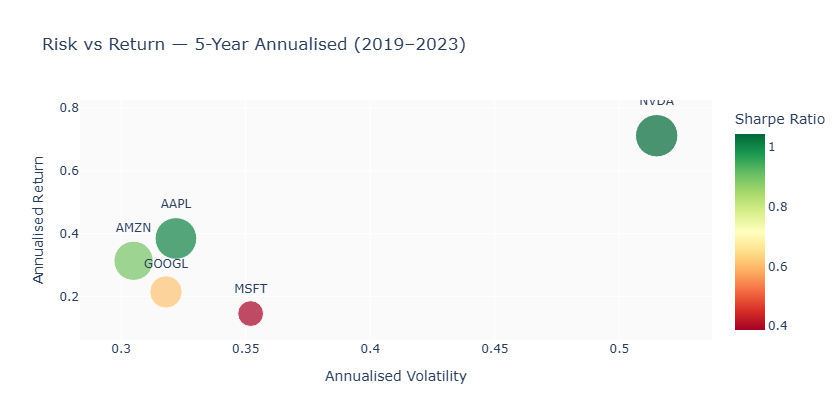

In [7]:
fig_rr = plot_risk_return(summary)
fig_rr.write_html("../outputs/plotly_risk_return.html")
fig_rr.write_image("../outputs/plotly_risk_return.png", scale=2)
fig_rr.show()

### Stage 5 — Communication: interactive finance dashboard

similiarly, run `streamlit run finance_dashboard.py` in the terminal

## Case Study 3 — IoT: Sensor Stream Monitoring

In [9]:
import sys
import os
sys.path.append(os.path.abspath("../data"))

import pandas as pd
import urllib.request
import zipfile

from config import IOT_CONFIG

os.makedirs(str(IOT_CONFIG["raw_dir"]), exist_ok=True)
url  = ("https://archive.ics.uci.edu/static/public/360/"
        "air+quality.zip")
dest = str(IOT_CONFIG["raw_dir"] / "air_quality.zip")

if not os.path.exists(dest):
    urllib.request.urlretrieve(url, dest)
    with zipfile.ZipFile(dest) as z:
        z.extractall(str(IOT_CONFIG["raw_dir"]))
        print("Extracted:", z.namelist())

Extracted: ['AirQualityUCI.csv', 'AirQualityUCI.xlsx']


### Stage 1 — Ingestion and audit

In [10]:
import pandas as pd
import numpy as np
sys.path.append(os.path.abspath("../src"))
from config import IOT_CONFIG

df_raw = pd.read_csv(
    IOT_CONFIG["raw_dir"] / IOT_CONFIG["filename"],
    sep=";", decimal=","
)

# Drop trailing empty columns and rows
df_raw = df_raw.dropna(how="all", axis=1)
df_raw = df_raw.dropna(how="all", axis=0)

print(df_raw.shape)           # (9471, 15)
print(df_raw.head(3))
print("\nMissing value encoding -200:")
print((df_raw == -200).sum())

(9357, 15)
         Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
0  10/03/2004  18.00.00     2.6       1360.0     150.0      11.9   
1  10/03/2004  19.00.00     2.0       1292.0     112.0       9.4   
2  10/03/2004  20.00.00     2.2       1402.0      88.0       9.0   

   PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
0         1046.0    166.0        1056.0    113.0        1692.0       1268.0   
1          955.0    103.0        1174.0     92.0        1559.0        972.0   
2          939.0    131.0        1140.0    114.0        1555.0       1074.0   

      T    RH      AH  
0  13.6  48.9  0.7578  
1  13.3  47.7  0.7255  
2  11.9  54.0  0.7502  

Missing value encoding -200:
Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T        

### Stage 2 — Cleaning and datetime parsing

In [13]:
from config import IOT_CONFIG

# Parse datetime
df_raw["datetime"] = pd.to_datetime(
    df_raw["Date"].astype(str) + " " + df_raw["Time"].astype(str),
    format="%d/%m/%Y %H.%M.%S",
    errors="coerce"
)
df = df_raw.drop(columns=["Date","Time"]).dropna(subset=["datetime"])
df = df.set_index("datetime").sort_index()

# Replace sensor error code -200 with NaN
df = df.replace(-200, np.nan)

# Select key channels from config
df = df[IOT_CONFIG["sensors"]].copy()

# Forward-fill short gaps using limit from config
df = df.ffill(limit=IOT_CONFIG["ffill_limit"])

# Drop rows where all sensors are still NaN
df = df.dropna(how="all")

print(f"Clean shape: {df.shape}")
print(f"Date range: {df.index.min()} → {df.index.max()}")
print(f"\nRemaining nulls:\n{df.isnull().sum()}")

Clean shape: (9335, 5)
Date range: 2004-03-10 18:00:00 → 2005-04-04 14:00:00

Remaining nulls:
CO(GT)         1399
PT08.S1(CO)     302
C6H6(GT)        302
T               302
RH              302
dtype: int64


### Stage 3 — EDA: temporal patterns

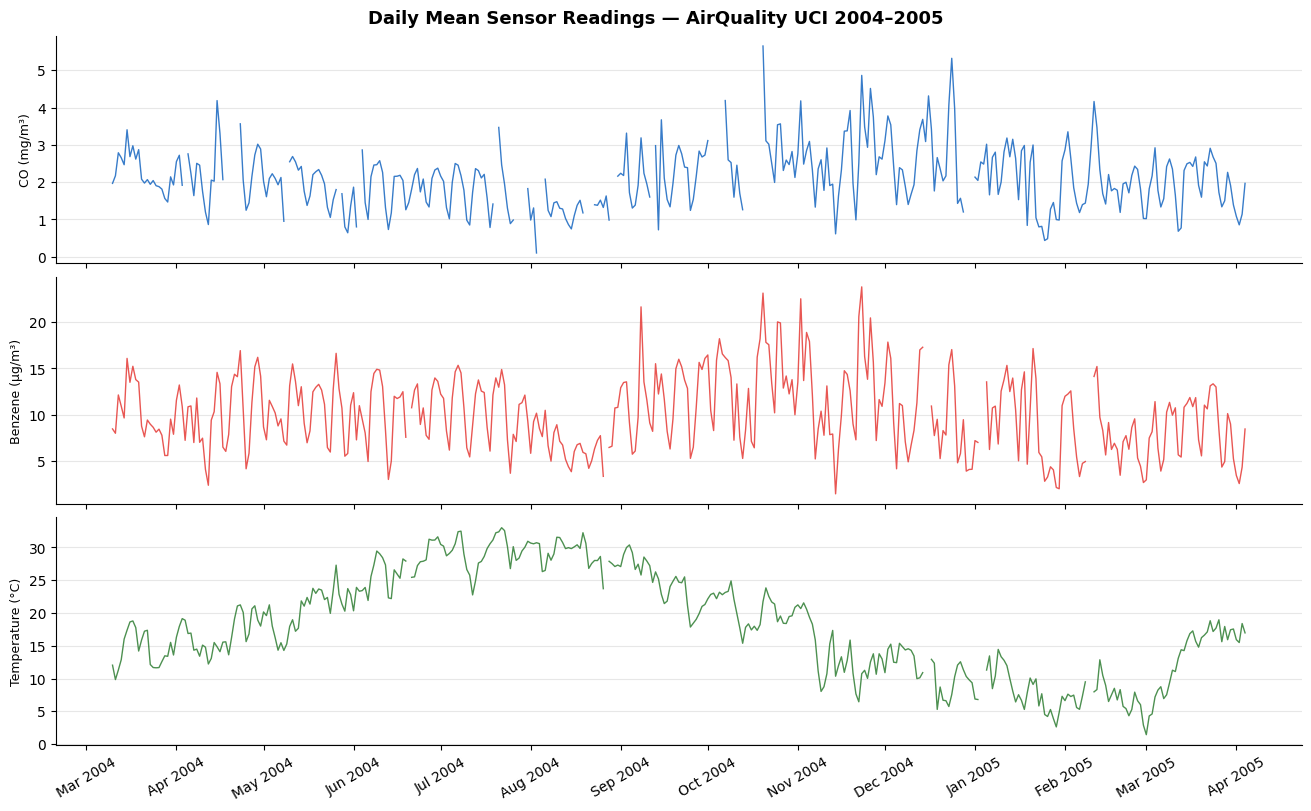

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(13, 8),
                         sharex=True, constrained_layout=True)

sensors = ["CO(GT)", "C6H6(GT)", "T"]
colors  = ["#1565C0", "#E53935", "#2E7D32"]
labels  = ["CO (mg/m³)", "Benzene (µg/m³)", "Temperature (°C)"]

for ax, sensor, color, label in zip(axes, sensors, colors, labels):
    daily = df[sensor].resample("1D").mean()
    ax.plot(daily.index, daily.values,
            color=color, linewidth=1, alpha=0.85)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
fig.suptitle("Daily Mean Sensor Readings — AirQuality UCI 2004–2005",
             fontsize=13, fontweight="bold")
plt.savefig("../outputs/iot_time_series.png", dpi=150)
plt.show()

In [15]:
# Hourly heatmap: average CO by hour and month
from lets_plot import *
LetsPlot.setup_html()

df_heat = df["CO(GT)"].copy().dropna()
df_heat = pd.DataFrame({
    "month": df_heat.index.strftime("%Y-%m"),
    "hour":  df_heat.index.hour,
    "CO":    df_heat.values
})
heat = df_heat.groupby(["month","hour"])["CO"].mean().round(3).reset_index()

p_heat = (
    ggplot(heat, aes(x="hour", y="month", fill="CO"))
    + geom_tile(color="white", size=0.3)
    + scale_fill_gradient(low="#FFF9C4", high="#B71C1C",
                           name="CO (mg/m³)")
    + labs(title="Mean CO Concentration — Hour × Month",
           x="Hour of Day", y="Month")
    + theme_minimal()
    + ggsize(750, 500)
)

# Save the plots
from pathlib import Path
output_path = Path("../outputs/").resolve()
# Save the heatmap
p_heat_html = "ggplot_co_heatmap.html"
ggsave(p_heat, filename=str(output_path / p_heat_html))
p_heat_png = "ggplot_co_heatmap.png"
ggsave(p_heat, filename=str(output_path / p_heat_png), scale=2)

p_heat

### Stage 4 — Anomaly detection with rolling z-scores

Total readings:  7,936
Anomalies found: 65 (0.82%)


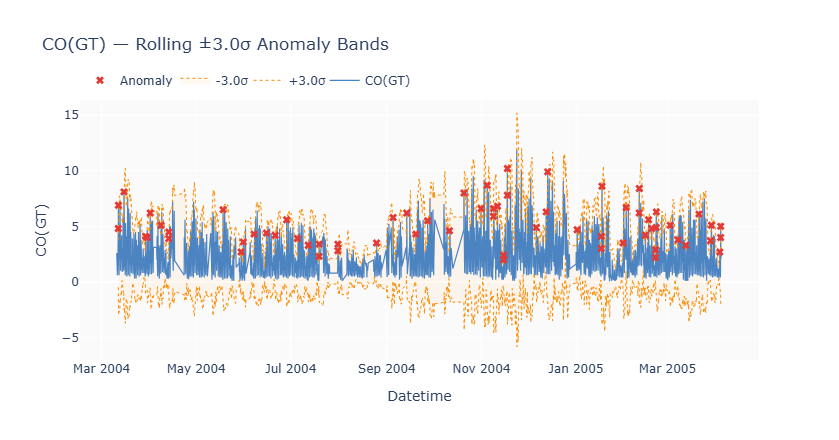

In [16]:
from pipeline import detect_anomalies, plot_anomaly_chart
from config import IOT_CONFIG

sensor = "CO(GT)"
series = df[sensor].dropna()

roll_mean, roll_std, z_score, anomalies = detect_anomalies(
    series,
    window=IOT_CONFIG["window"],
    threshold=IOT_CONFIG["threshold"],
)

print(f"Total readings:  {len(series):,}")
print(f"Anomalies found: {len(anomalies):,} "
      f"({len(anomalies)/len(series)*100:.2f}%)")

fig = plot_anomaly_chart(
    series, roll_mean, roll_std, anomalies,
    threshold=IOT_CONFIG["threshold"],
    sensor=sensor
)

# Save the anomaly chart
fig.write_html("../outputs/plotly_anomaly_chart.html")
fig.write_image("../outputs/plotly_anomaly_chart.png", scale=2)

fig.show()

### Stage 5 — Communication: real-time IoT dashboard

Run this from the project root folder in the terminal:

```bash
cd src
streamlit run iot_dashboard.py
```